<a href="https://colab.research.google.com/github/DanielHevdeli/hafifot-tiug/blob/main/train_bert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from huggingface_hub import notebook_login
notebook_login()

In [2]:
from huggingface_hub import snapshot_download

# This downloads everything to a folder named 'c14_data'
snapshot_download(
    repo_id="js1699344/c14_articles",
    repo_type="dataset",
    local_dir="c14_data"
)

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

'C:\\Users\\Daniel Hevdeli\\Downloads\\hafifot-tiug\\notebooks\\c14_data'

In [3]:
import pandas as pd

NOTE: we are working only with the present data!

In [7]:
DATA_GROUP = "present"

In [13]:
data = pd.read_json(f'c14_data/data_split/{DATA_GROUP}/articles.jsonl', lines=True)
metadata = pd.read_csv(f'c14_data/data_split/{DATA_GROUP}/articles_metadata.csv')
metadata.head()

,id,date,wordsCount,author,archive_ids
0,691552,2022-09-15 10:22,739,דור אזרד,"63587,4329"
1,690427,2022-09-08 18:18,226,מערכת C14,"63587,4329"
2,690016,2022-09-07 21:44,422,מערכת C14,"63587,4329"
3,688340,2022-09-04 17:35,435,יצחק אבוחצירא,"63587,4329"
4,686593,2022-08-30 18:07,535,טל אזולאי אבידן,"63587,4329"


In [14]:
data.head()

,source,date,article_id,length,author,text
0,c14,2025-02-24 12:24:00,1128186,1176,רבקה שורק,פורום “בוחרים בחיים” של המשפחות השכולות הגיש ה...
1,c14,2025-02-24 12:17:00,1127982,1535,דין ברנדשטטר,שר התרבות והספורט מיקי זוהר הגיב הבוקר (שני) ל...
2,c14,2025-02-24 12:07:00,1128178,1337,יצחק אבוחצירא,"תלונה הוגשה ליועמ""שית גלי בהרב-מיארה בעניינו ש..."
3,c14,2025-02-24 11:46:00,1128035,858,רבקה שורק,"בעקבות נפילת נשיא סוריה לשעבר בשאר אל אסד, ולא..."
4,c14,2025-02-24 11:36:00,1128104,466,אור צעידי,קבוצת הכדורגל בני סכנין עלולה לעמוד לדין במידה...


In [15]:
print(f"Num of articles: {len(data)}")

Num of articles: 43536


For now, we will use only the `nvidia/nemotron-3-nano-30b-a3b-bf16` annotator

In [16]:
ANNOTATOR = "nvidia/nemotron-3-nano-30b-a3b-bf16"

In [17]:
annotations = pd.read_csv(f"c14_data/data_split/{DATA_GROUP}/annotations/{ANNOTATOR}.csv")

In [21]:
annotated_data = pd.merge(data, annotations[["article_id", "label"]], on='article_id')

In [22]:
annotated_data.head()

,source,date,article_id,length,author,text,label
0,c14,2025-02-24 12:24:00,1128186,1176,רבקה שורק,פורום “בוחרים בחיים” של המשפחות השכולות הגיש ה...,biased
1,c14,2025-02-24 12:17:00,1127982,1535,דין ברנדשטטר,שר התרבות והספורט מיקי זוהר הגיב הבוקר (שני) ל...,biased
2,c14,2025-02-24 12:07:00,1128178,1337,יצחק אבוחצירא,"תלונה הוגשה ליועמ""שית גלי בהרב-מיארה בעניינו ש...",biased
3,c14,2025-02-24 11:46:00,1128035,858,רבקה שורק,"בעקבות נפילת נשיא סוריה לשעבר בשאר אל אסד, ולא...",neutral
4,c14,2025-02-24 11:36:00,1128104,466,אור צעידי,קבוצת הכדורגל בני סכנין עלולה לעמוד לדין במידה...,neutral


In [25]:
n_total = len(annotated_data)
n_unknown = annotated_data[annotated_data['label'] == 'unknown'].shape[0]
print(f"Num of Unknowns: {n_unknown}/{n_total} ({100 * (n_unknown / n_total)}%)")

Num of Unknowns: 0/43536 (0.0%)


In [26]:
def get_classes_frequencies(df, label_col='label'):
    class_counts = df[label_col].value_counts()
    class_percentages = 100 * class_counts / len(df)
    return class_counts, class_percentages

In [27]:
print("Class Distribution:")
class_counts, class_percentages = get_classes_frequencies(annotated_data)

class_distribution_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percentages
})
class_distribution_df.index.name = 'Label'
display(class_distribution_df.round(2))

Class Distribution:


,Count,Percentage
Label,,
neutral,22715,52.18
biased,20821,47.82


# Create a BERT Classifier

In [32]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [36]:
from datasets import Dataset, DatasetDict

import numpy as np
import matplotlib.pyplot as plt

In [39]:
import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [ ]:
import torch
import torch.nn as nn

In [28]:
CLASSES = annotations['label'].unique().tolist()
id2label = {i: label for i, label in enumerate(CLASSES)}
label2id = {label: i for i, label in enumerate(CLASSES)}

print(CLASSES)
print(id2label)
print(label2id)

['neutral', 'biased']
{0: 'neutral', 1: 'biased'}
{'neutral': 0, 'biased': 1}


In [29]:
df = annotated_data.copy()
df["labels"] = df["label"].map(label2id)

In [30]:
TEST_SIZE = 0.2

In [33]:
train_df, test_df = train_test_split(df, test_size=TEST_SIZE, stratify=df["labels"], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=TEST_SIZE, stratify=train_df["labels"], random_state=42)

In [37]:
train_ds = Dataset.from_pandas(train_df[["text", "labels"]])
val_ds   = Dataset.from_pandas(val_df[["text", "labels"]])
test_ds  = Dataset.from_pandas(test_df[["text", "labels"]])

ds = DatasetDict({"train": train_ds, "validation": val_ds, "test": test_ds})

In [40]:
MODEL_NAME = "onlplab/alephbert-base" #FIX: truncation of all posts...
model_short_name = MODEL_NAME.split("/")[-1]
MODEL_CONTEXT_LEN = 512
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [41]:
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MODEL_CONTEXT_LEN)

ds = ds.map(tokenize, batched=True)

Map:   0%|          | 0/27862 [00:00<?, ? examples/s]

Map:   0%|          | 0/6966 [00:00<?, ? examples/s]

Map:   0%|          | 0/8708 [00:00<?, ? examples/s]

In [ ]:
ds = ds.remove_columns(["text"])
ds.set_format(type="torch")

In [43]:
ds

DatasetDict({
    train: Dataset({
        features: ['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 27862
    })
    validation: Dataset({
        features: ['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 6966
    })
    test: Dataset({
        features: ['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8708
    })
})

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id
)

In [24]:
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(52000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [25]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

bert.embeddings.word_embeddings.weight
bert.embeddings.position_embeddings.weight
bert.embeddings.token_type_embeddings.weight
bert.embeddings.LayerNorm.weight
bert.embeddings.LayerNorm.bias
bert.encoder.layer.0.attention.self.query.weight
bert.encoder.layer.0.attention.self.query.bias
bert.encoder.layer.0.attention.self.key.weight
bert.encoder.layer.0.attention.self.key.bias
bert.encoder.layer.0.attention.self.value.weight
bert.encoder.layer.0.attention.self.value.bias
bert.encoder.layer.0.attention.output.dense.weight
bert.encoder.layer.0.attention.output.dense.bias
bert.encoder.layer.0.attention.output.LayerNorm.weight
bert.encoder.layer.0.attention.output.LayerNorm.bias
bert.encoder.layer.0.intermediate.dense.weight
bert.encoder.layer.0.intermediate.dense.bias
bert.encoder.layer.0.output.dense.weight
bert.encoder.layer.0.output.dense.bias
bert.encoder.layer.0.output.LayerNorm.weight
bert.encoder.layer.0.output.LayerNorm.bias
bert.encoder.layer.1.attention.self.query.weight
bert.enc

In [28]:
for param in model.bert.encoder.parameters():
    param.requires_grad = False
for param in model.bert.embeddings.parameters():
    param.requires_grad = False

In [31]:
print("Trainable Params:\n")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

Trainable Params:

bert.pooler.dense.weight
bert.pooler.dense.bias
classifier.weight
classifier.bias


In [46]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
total     = trainable + frozen

print(f"Trainable: {trainable:,} ({trainable/total*100:.2f}%)")
print(f"Frozen:    {frozen:,} ({frozen/total*100:.2f}%)")
print(f"Total:     {total:,}")


Trainable: 592,130 (0.47%)
Frozen:    125,385,984 (99.53%)
Total:     125,978,114


In [32]:
def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)

    # per-class accuracy
    correct_per_class = []
    for cls in [0, 1]:
        mask = (labels == cls)
        if mask.sum() == 0:
            continue  # no samples of this class in this batch
        class_acc = (preds[mask] == cls).mean()
        correct_per_class.append(class_acc)

    # min accuracy among classes
    if len(correct_per_class) == 0:
        min_acc = 0.0
    else:
        min_acc = min(correct_per_class)

    return {
        "accuracy": acc,
        "min_accuracy": min_acc,
    }

In [33]:
BATCH_SIZE = 16
EPOCHS = 20

In [34]:
print("Train Class Distribution:")
class_counts, class_percentages = get_classes_frequencies(train_df, label_col="labels")

class_distribution_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percentages
})
class_distribution_df.index.name = 'Label'
display(class_distribution_df.round(2))

Train Class Distribution:


,Count,Percentage
Label,,
0,2379,92.93
1,181,7.07


In [35]:
training_args = TrainingArguments(
    report_to=[],  # I dont want to save my expirements to W&B or tensorboard
    output_dir=f"./hafifot-tiug/models/{model_short_name}",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="min_accuracy",
    greater_is_better=True,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    fp16=True
)

In [36]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [37]:
# dealing with class imbalance
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["labels"]),
    y=train_df["labels"]
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights = class_weights.to(model.device)
print(f"Class weights: {class_weights}")

Class weights: tensor([0.5380, 7.0718])


### Weighted CE Trainer

In [38]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        if labels is None:
            raise ValueError("Labels not found in inputs for computing loss")

        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")
        if logits is None:
            raise ValueError("Logits not found in model outputs")

        # Make sure class_weights is on the same device as logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss


### Focal Loss Trainer

In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        """
        logits: (B, C)
        targets: (B,)
        """
        log_probs = F.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)
        targets_one_hot = F.one_hot(targets, num_classes=logits.size(1)).float()
        focal_factor = (1 - probs) ** self.gamma

        alpha_factor = torch.ones_like(probs)
        alpha_factor[:, 1] = self.alpha
        alpha_factor[:, 0] = 1 - self.alpha

        loss = -alpha_factor * focal_factor * targets_one_hot * log_probs
        loss = loss.sum(dim=1)  # sum over classes

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:  # per-sample
            return loss

In [40]:
class FocalTrainer(Trainer):
    def __init__(self, alpha=0.75, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.focal_loss_fn = FocalLoss(alpha=alpha, gamma=gamma, reduction="mean")

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """
        Override compute_loss to use focal loss instead of standard CE.
        """
        labels = inputs.get("labels")
        if labels is None:
            raise ValueError("Labels not found in inputs for computing loss")

        outputs = model(**inputs)
        logits = outputs.get("logits")
        if logits is None:
            raise ValueError("Logits not found in model outputs")

        loss = self.focal_loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

### Over Sampling Trainer

In [41]:
# ds["train"] = ds["train"].remove_columns("__index_level_0__")
# ds["validation"] = ds["validation"].remove_columns("__index_level_0__")

In [42]:
from torch.utils.data import DataLoader, WeightedRandomSampler

labels = np.array(train_df['labels'])
class_counts = np.bincount(labels)
weights_per_class = 1.0 / class_counts
sample_weights = weights_per_class[labels]
print(f"Class weights: {weights_per_class}")

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,  # allows repeating minority examples
)

Class weights: [0.00042034 0.00552486]


In [43]:
class OversampleTrainer(Trainer):
    def get_train_dataloader(self):
        if self.train_dataset is None:
            raise ValueError("Trainer: training requires a train_dataset.")
        return DataLoader(
            self.train_dataset,
            batch_size=self.args.train_batch_size,
            sampler=sampler,           # apply oversampling
            collate_fn=self.data_collator,  # your existing collator
            drop_last=self.args.dataloader_drop_last,
            num_workers=self.args.dataloader_num_workers,
        )


### Use Trainer

In [44]:
trainer = FocalTrainer(
    model=model,
    args=training_args,
    train_dataset=ds["train"],
    eval_dataset=ds["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    # callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [45]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Min Accuracy
1,0.035500,0.031426,0.928125,0.022222
2,0.032100,0.029106,0.906250,0.244444
3,0.031500,0.028164,0.910937,0.244444
4,0.030000,0.027981,0.921875,0.177778
5,0.029600,0.028320,0.920312,0.177778
6,0.029500,0.028242,0.895312,0.377778
7,0.029100,0.027462,0.914062,0.311111
8,0.028700,0.027774,0.907813,0.311111
9,0.028200,0.028694,0.893750,0.400000
10,0.028500,0.028046,0.912500,0.333333


TrainOutput(global_step=3200, training_loss=0.028902256786823274, metrics={'train_runtime': 702.7948, 'train_samples_per_second': 72.852, 'train_steps_per_second': 4.553, 'total_flos': 1.319565253728096e+16, 'train_loss': 0.028902256786823274, 'epoch': 20.0})

### Plot History and Metircs

In [47]:
history = trainer.state.log_history

train_logs = [h for h in trainer.state.log_history if "loss" in h and "eval_loss" not in h]
val_logs   = [h for h in trainer.state.log_history if "eval_loss" in h]

In [48]:
def extract(logs, keys):
    data = {k: [] for k in keys}
    for h in logs:
        for k in keys:
            data[k].append(h.get(k, None))
    return data

train_loss = extract(train_logs, ["loss"])
val_metrics = extract(val_logs, ["eval_loss", "eval_accuracy", "eval_min_accuracy"])

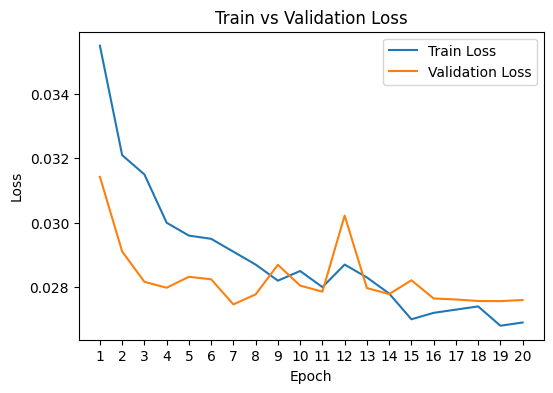

In [49]:
epochs = range(1, len(train_loss["loss"]) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, train_loss["loss"], label="Train Loss")
plt.plot(epochs, val_metrics["eval_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.show()

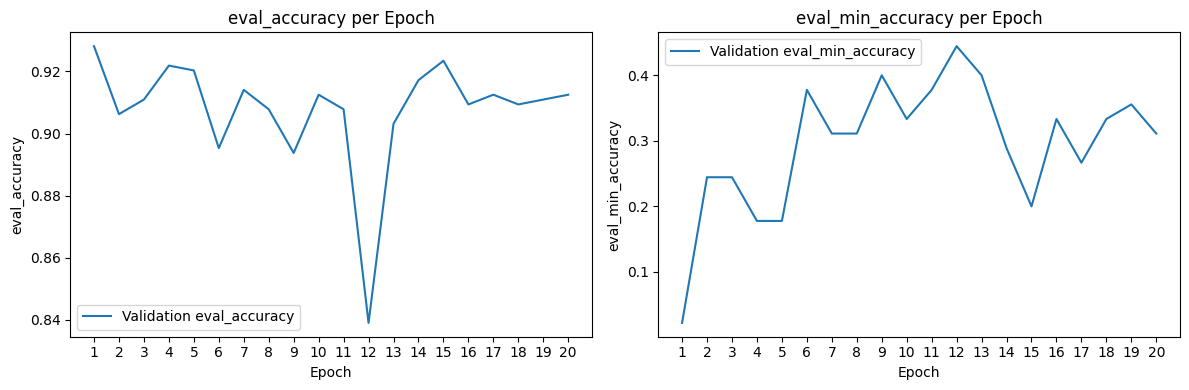

In [50]:
metric_names = ["eval_accuracy", "eval_min_accuracy"]
num_metrics = len(metric_names)

# create a single row of subplots
fig, axes = plt.subplots(1, num_metrics, figsize=(6*num_metrics, 4))  # width scales with number of metrics

for i, metric in enumerate(metric_names):
    ax = axes[i] if num_metrics > 1 else axes
    ax.plot(epochs, val_metrics[metric], label=f"Validation {metric}")
    ax.set_xlabel("Epoch")
    ax.set_xticks(epochs)
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} per Epoch")
    ax.legend()

plt.tight_layout()
plt.show()

In [51]:
def print_classification_report(texts, title):
    pred = trainer.predict(texts)
    logits = pred.predictions
    labels = pred.label_ids
    preds = logits.argmax(-1)

    print(f"\n====== CLASSIFICATION REPORT ({title}) ======\n")
    print(classification_report(labels, preds, target_names=list(id2label.values())))

In [52]:
print_classification_report(ds["train"], title="Train")


====== CLASSIFICATION REPORT (Train) ======

                   precision    recall  f1-score   support

non-suicidal-risk       0.97      0.85      0.91      2379
    suicidal-risk       0.25      0.64      0.36       181

         accuracy                           0.84      2560
        macro avg       0.61      0.75      0.63      2560
     weighted avg       0.92      0.84      0.87      2560



In [53]:
print_classification_report(ds["validation"], title="Validation")


====== CLASSIFICATION REPORT (Validation) ======

                   precision    recall  f1-score   support

non-suicidal-risk       0.95      0.87      0.91       595
    suicidal-risk       0.20      0.44      0.28        45

         accuracy                           0.84       640
        macro avg       0.58      0.66      0.59       640
     weighted avg       0.90      0.84      0.87       640



I will improve later by addressing the class imbalance properly.

In [54]:
def predict(texts):
    enc = tokenizer(texts, truncation=True, padding=True, return_tensors="pt").to(model.device)
    with torch.no_grad():
      logits = model(**enc).logits
    preds = logits.argmax(dim=-1).cpu().numpy()
    return [id2label[int(p)] for p in preds]

In [55]:
print(predict([
    " כבר תקופה אני מרגישה ממש רע וחושבת דברים אובדניים",
    "איזה יום טוב היה לי היום"
]))

['non-suicidal-risk', 'non-suicidal-risk']


In [56]:
# print_classification_report(ds["test"], title="Test")

### Save Model